# Ch03 — PPO lite na CartPole — wersja rozgrzewkowa

PPO w skrócie:
- zbieramy rollout,
- liczymy advantage (tu: prosty GAE),
- aktualizujemy politykę przez **clipped surrogate**:
  $L^{CLIP} = \mathbb{E}[\min(r_t A_t, \text{clip}(r_t, 1-\epsilon, 1+\epsilon)A_t)]$
  gdzie $r_t = \exp(\log\pi_\theta - \log\pi_{\theta_{old}})$
- uczymy też critic (value loss) + opcjonalnie entropy bonus.


In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym


# --- device (jak u Ciebie) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


# --- reproducibility ---
def seed_everything(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# --- env wrappers (jak w Ch01) ---
def make_env(env_id="CartPole-v1", seed=0, render=False):
    env = gym.make(env_id, render_mode=("human" if render else None))
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

def reset_env(env, seed=None):
    obs, _ = env.reset(seed=seed)
    return obs

def step_env(env, action):
    obs2, r, terminated, truncated, _ = env.step(int(action))
    done = bool(terminated or truncated)
    return obs2, float(r), done


# --- evaluation (jak w Ch01): policy_fn(obs)->action(int) ---
def evaluate_policy(env_id, policy_fn, episodes=20, seed=123):
    env = make_env(env_id, seed=seed, render=False)
    rets = []
    for k in range(episodes):
        obs = reset_env(env, seed=seed + k)
        done = False
        ep_ret = 0.0
        while not done:
            a = int(policy_fn(obs))
            obs, r, done = step_env(env, a)
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def moving_average(x, w=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")


device = cpu


In [2]:
class ActorNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, act_dim),   # logits
        )
    def forward(self, x):
        return self.net(x)

class CriticNet(nn.Module):
    def __init__(self, obs_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),        # V(s)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)   # (B,)


In [3]:
# --- action helpers (spójne z A2C; potrzebne do evaluate_policy) ---
@torch.no_grad()
def a2c_act_greedy(actor: ActorNet, obs):
    x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    logits = actor(x).squeeze(0)
    return int(torch.argmax(logits).item())

@torch.no_grad()
def a2c_act_sample(actor: ActorNet, obs):
    x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    logits = actor(x).squeeze(0)
    dist = torch.distributions.Categorical(logits=logits)
    return int(dist.sample().item())


In [4]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    rewards: list[float] length T
    values:  np.array length T+1 (V(s_t) + bootstrap V(s_{T}))
    dones:   list[bool] length T
    returns: (adv, ret) arrays length T
    """
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        mask = 0.0 if dones[t] else 1.0
        delta = rewards[t] + gamma * values[t+1] * mask - values[t]
        gae = delta + gamma * lam * mask * gae
        adv[t] = gae
    ret = adv + values[:-1]
    return adv, ret


In [5]:
def train_ppo_lite(
    seed=0,
    episodes=300,
    gamma=0.99,
    lam=0.95,
    lr=3e-4,
    hidden=128,
    clip_eps=0.2,
    entropy_coef=0.01,
    value_coef=0.5,
    train_epochs=4,
    batch_size=64,
    grad_clip=10.0,
    eval_every=50,
    eval_episodes=20,
):
    seed_everything(seed)
    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = ActorNet(obs_dim, act_dim, hidden=hidden).to(device)
    critic = CriticNet(obs_dim, hidden=hidden).to(device)
    opt = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=lr)

    returns_hist = []
    pol_loss_hist = []
    val_loss_hist = []
    eval_points = []

    for ep in range(1, episodes + 1):
        obs = reset_env(env, seed=seed + ep)

        states = []
        actions = []
        rewards = []
        dones = []
        logp_old = []
        values = []

        done = False
        while not done:
            x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = actor(x).squeeze(0)
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            lp = dist.log_prob(a)

            v = critic(x).squeeze(0)

            a_int = int(a.item())
            obs2, r, done = step_env(env, a_int)

            states.append(obs)
            actions.append(a_int)
            rewards.append(r)
            dones.append(done)
            logp_old.append(float(lp.item()))
            values.append(float(v.item()))

            obs = obs2

        # bootstrap value at terminal (or last obs)
        xT = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        vT = float(critic(xT).item())
        values = np.array(values + [vT], dtype=np.float32)  # length T+1

        adv, ret = compute_gae(rewards, values, dones, gamma=gamma, lam=lam)
        # normalize advantages (standard PPO trick)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # tensors
        s_t = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        a_t = torch.tensor(np.array(actions), dtype=torch.int64, device=device)
        logp_old_t = torch.tensor(np.array(logp_old), dtype=torch.float32, device=device)
        adv_t = torch.tensor(adv, dtype=torch.float32, device=device)
        ret_t = torch.tensor(ret, dtype=torch.float32, device=device)

        T = len(actions)
        idx_all = np.arange(T)

        # PPO updates
        ep_pol_losses = []
        ep_val_losses = []

        for _ in range(train_epochs):
            np.random.shuffle(idx_all)
            for start in range(0, T, batch_size):
                idx = idx_all[start:start+batch_size]
                bs = s_t[idx]
                ba = a_t[idx]
                bold = logp_old_t[idx]
                badv = adv_t[idx]
                bret = ret_t[idx]

                logits = actor(bs)
                dist = torch.distributions.Categorical(logits=logits)
                logp = dist.log_prob(ba)
                entropy = dist.entropy().mean()

                ratio = torch.exp(logp - bold)
                surr1 = ratio * badv
                surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * badv
                policy_loss = -torch.min(surr1, surr2).mean() - entropy_coef * entropy

                V = critic(bs)
                value_loss = F.smooth_l1_loss(V, bret)

                loss = policy_loss + value_coef * value_loss

                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(list(actor.parameters()) + list(critic.parameters()), grad_clip)
                opt.step()

                ep_pol_losses.append(float(policy_loss.item()))
                ep_val_losses.append(float(value_loss.item()))

        ep_ret = float(np.sum(rewards))
        returns_hist.append(ep_ret)
        pol_loss_hist.append(float(np.mean(ep_pol_losses)))
        val_loss_hist.append(float(np.mean(ep_val_losses)))

        if ep % 20 == 0:
            ma50 = np.mean(returns_hist[-50:]) if len(returns_hist) >= 50 else np.mean(returns_hist)
            print(f"ep {ep:4d} | return={ep_ret:6.1f} | MA50={ma50:6.1f} | polL={pol_loss_hist[-1]:.3f} | valL={val_loss_hist[-1]:.3f}")

        if eval_every and (ep % eval_every == 0):
            m, s = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor, ob), episodes=eval_episodes, seed=123)
            eval_points.append((ep, m))
            print(f"   [eval] ep {ep:4d} | greedy mean±std = {m:6.1f} ± {s:4.1f}")

    env.close()
    stats = {
        "returns": returns_hist,
        "policy_loss": pol_loss_hist,
        "value_loss": val_loss_hist,
        "eval_points": eval_points,
    }
    return actor, critic, stats


ep   20 | return=  11.0 | MA50=  30.4 | polL=-0.010 | valL=3.198
ep   40 | return=  26.0 | MA50=  24.8 | polL=-0.017 | valL=6.006
   [eval] ep   50 | greedy mean±std =   29.8 ±  4.6
ep   60 | return=  23.0 | MA50=  27.8 | polL=-0.003 | valL=4.866
ep   80 | return= 145.0 | MA50=  42.7 | polL=-0.023 | valL=10.801
ep  100 | return= 120.0 | MA50=  75.1 | polL=-0.004 | valL=11.971
   [eval] ep  100 | greedy mean±std =  151.4 ± 13.8
ep  120 | return= 159.0 | MA50= 115.2 | polL=0.002 | valL=8.730
ep  140 | return= 174.0 | MA50= 156.2 | polL=-0.002 | valL=5.230
   [eval] ep  150 | greedy mean±std =  370.8 ± 96.0
ep  160 | return=  70.0 | MA50= 170.7 | polL=-0.018 | valL=12.004
ep  180 | return= 309.0 | MA50= 182.4 | polL=-0.014 | valL=3.423
ep  200 | return=  64.0 | MA50= 192.1 | polL=-0.009 | valL=18.735
   [eval] ep  200 | greedy mean±std =  270.9 ± 20.2
ep  220 | return= 187.0 | MA50= 231.5 | polL=-0.011 | valL=6.263
ep  240 | return= 274.0 | MA50= 305.4 | polL=-0.022 | valL=5.081
   [eval]

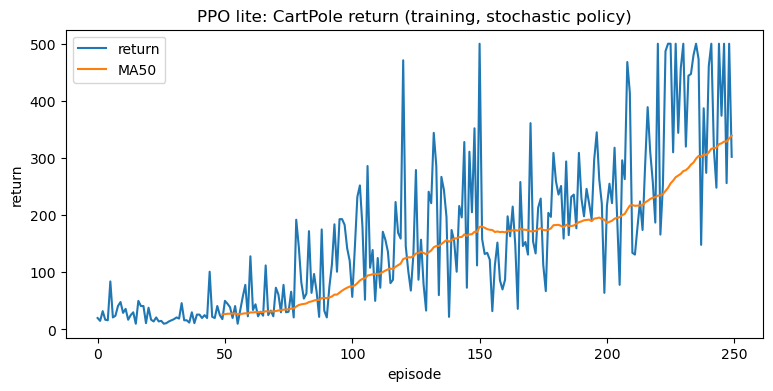

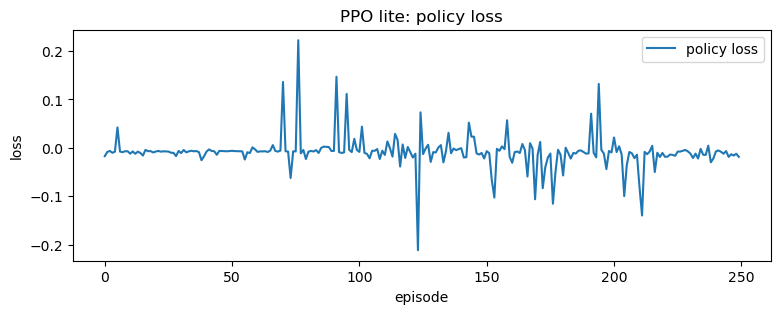

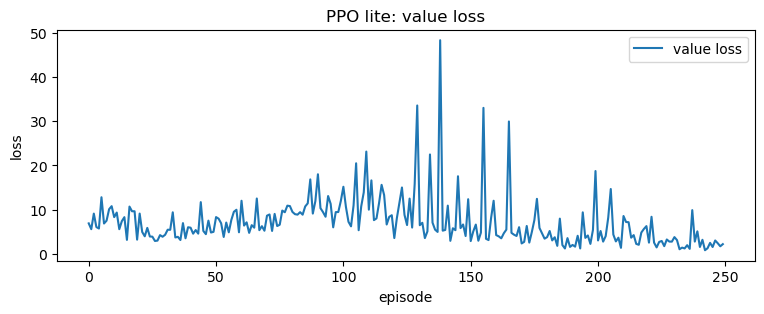

In [6]:
actor_ppo, critic_ppo, stp = train_ppo_lite(
    seed=0,
    episodes=250,
    lr=3e-4,
    clip_eps=0.2,
    lam=0.95,
    train_epochs=4,
    eval_every=50,
)

plt.figure(figsize=(9,4))
plt.plot(stp["returns"], label="return")
plt.plot(np.arange(len(moving_average(stp["returns"],50)))+49, moving_average(stp["returns"],50), label="MA50")
plt.title("PPO lite: CartPole return (training, stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(stp["policy_loss"], label="policy loss")
plt.title("PPO lite: policy loss")
plt.xlabel("episode")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(stp["value_loss"], label="value loss")
plt.title("PPO lite: value loss")
plt.xlabel("episode")
plt.ylabel("loss")
plt.legend()
plt.show()


# Ćwiczenia 

In [7]:
if "compute_gae" not in globals():
    def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
        """
        rewards: list length T
        values:  np.array length T+1 (z bootstrapem)
        dones:   list length T (True na końcu)
        """
        T = len(rewards)
        adv = np.zeros(T, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(T)):
            mask = 0.0 if dones[t] else 1.0
            delta = rewards[t] + gamma * values[t+1] * mask - values[t]
            gae = delta + gamma * lam * mask * gae
            adv[t] = gae
        ret = adv + values[:-1]
        return adv, ret


In [8]:
def train_ppo_runner(
    *,
    seed=0,
    episodes=220,
    gamma=0.99,
    lam=0.95,
    lr=3e-4,
    hidden=128,
    clip_eps=0.2,
    entropy_coef=0.01,
    value_coef=0.5,
    train_epochs=4,
    batch_size=64,
    grad_clip=10.0,
    eval_every=55,
    eval_episodes=20,
    # wstrzykiwane "klocki":
    policy_loss_fn=None,    # policy_loss_fn(logp, logp_old, adv, clip_eps) -> scalar
    gae_fn=None,            # gae_fn(rewards, values, dones, gamma, lam) -> (adv_np, ret_np)
    adv_norm_fn=None,       # adv_norm_fn(adv_tensor)->adv_tensor lub None
):
    assert policy_loss_fn is not None
    assert gae_fn is not None

    seed_everything(seed)
    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = ActorNet(obs_dim, act_dim, hidden=hidden).to(device)
    critic = CriticNet(obs_dim, hidden=hidden).to(device)
    opt = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=lr)

    returns_hist = []
    pol_loss_hist = []
    val_loss_hist = []
    eval_points = []

    for ep in range(1, episodes + 1):
        obs = reset_env(env, seed=seed + ep)

        states, actions, rewards, dones = [], [], [], []
        logp_old, values = [], []

        done = False
        while not done:
            x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = actor(x).squeeze(0)
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            lp = dist.log_prob(a)
            v = critic(x).squeeze(0)

            a_int = int(a.item())
            obs2, r, done = step_env(env, a_int)

            states.append(obs)
            actions.append(a_int)
            rewards.append(float(r))
            dones.append(bool(done))
            logp_old.append(float(lp.item()))
            values.append(float(v.item()))

            obs = obs2

        # bootstrap value
        xT = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        vT = float(critic(xT).item())
        values_np = np.array(values + [vT], dtype=np.float32)  # T+1

        adv_np, ret_np = gae_fn(rewards, values_np, dones, gamma=gamma, lam=lam)

        s_t = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        a_t = torch.tensor(np.array(actions), dtype=torch.int64, device=device)
        logp_old_t = torch.tensor(np.array(logp_old), dtype=torch.float32, device=device)
        adv_t = torch.tensor(adv_np, dtype=torch.float32, device=device)
        ret_t = torch.tensor(ret_np, dtype=torch.float32, device=device)

        if adv_norm_fn is not None:
            adv_t = adv_norm_fn(adv_t)

        T = len(actions)
        idx_all = np.arange(T)

        ep_pol_losses = []
        ep_val_losses = []

        for _ in range(train_epochs):
            np.random.shuffle(idx_all)
            for start in range(0, T, batch_size):
                idx = idx_all[start:start+batch_size]
                bs = s_t[idx]
                ba = a_t[idx]
                bold = logp_old_t[idx]
                badv = adv_t[idx]
                bret = ret_t[idx]

                logits = actor(bs)
                dist = torch.distributions.Categorical(logits=logits)
                logp = dist.log_prob(ba)
                entropy = dist.entropy().mean()

                policy_loss = policy_loss_fn(logp, bold, badv, clip_eps)
                policy_loss = policy_loss - entropy_coef * entropy

                V = critic(bs)
                value_loss = F.smooth_l1_loss(V, bret)

                loss = policy_loss + value_coef * value_loss

                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(list(actor.parameters()) + list(critic.parameters()), grad_clip)
                opt.step()

                ep_pol_losses.append(float(policy_loss.item()))
                ep_val_losses.append(float(value_loss.item()))

        ep_ret = float(np.sum(rewards))
        returns_hist.append(ep_ret)
        pol_loss_hist.append(float(np.mean(ep_pol_losses)))
        val_loss_hist.append(float(np.mean(ep_val_losses)))

        if ep % 20 == 0:
            ma50 = np.mean(returns_hist[-50:]) if len(returns_hist) >= 50 else np.mean(returns_hist)
            print(f"ep {ep:4d} | return={ep_ret:6.1f} | MA50={ma50:6.1f} | polL={pol_loss_hist[-1]:.3f} | valL={val_loss_hist[-1]:.3f}")

        if eval_every and (ep % eval_every == 0):
            m, s = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor, ob), episodes=eval_episodes, seed=123)
            eval_points.append((ep, m))
            print(f"   [eval] ep {ep:4d} | greedy mean±std = {m:6.1f} ± {s:4.1f}")

    env.close()
    stats = {"returns": returns_hist, "policy_loss": pol_loss_hist, "value_loss": val_loss_hist, "eval_points": eval_points}
    return actor, critic, stats


# Ćwiczenie PPO-1 — Clipped objective (rdzeń PPO)

## Ćwiczenie PPO-1 — PPO clipped surrogate (rdzeń PPO)

**Cel:** zaimplementować kluczowy element PPO: clipped objective.

Definicje:
- ratio: $r_t = \exp(\log\pi_\theta(a_t|s_t) - \log\pi_{\theta_{old}}(a_t|s_t))$
- surrogate:
  - $surr1 = r_t A_t$
  - $surr2 = \text{clip}(r_t, 1-\epsilon, 1+\epsilon)A_t$
- loss:
$
L^{CLIP} = -\mathbb{E}[\min(surr1, surr2)]
$

**Zadanie:** uzupełnij `ppo_policy_loss_clipped`.


## TODO:

In [9]:
def ppo_policy_loss_clipped(logp: torch.Tensor, logp_old: torch.Tensor, adv: torch.Tensor, clip_eps: float) -> torch.Tensor:
    """
    logp, logp_old, adv: (B,)
    Zwróć scalar policy loss (z min i clip), z minusem na początku.

    TODO:
    - ratio = exp(logp - logp_old)
    - surr1 = ratio * adv
    - surr2 = clamp(ratio, 1-clip, 1+clip) * adv
    - return -mean(min(surr1, surr2))
    """
    raise NotImplementedError("TODO: PPO clipped surrogate loss")


## Rozwiązanie

In [10]:
def ppo_policy_loss_clipped(logp: torch.Tensor, logp_old: torch.Tensor, adv: torch.Tensor, clip_eps: float) -> torch.Tensor:
    ratio = torch.exp(logp - logp_old)
    surr1 = ratio * adv
    surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv
    return -torch.min(surr1, surr2).mean()


ep   20 | return=  11.0 | MA50=  30.4 | polL=-0.009 | valL=3.198
ep   40 | return=  35.0 | MA50=  25.4 | polL=-0.007 | valL=7.316
   [eval] ep   55 | greedy mean±std =   63.3 ± 17.6
ep   60 | return=  28.0 | MA50=  28.1 | polL=-0.006 | valL=5.105
ep   80 | return=  81.0 | MA50=  62.5 | polL=0.018 | valL=12.674
ep  100 | return=  96.0 | MA50=  88.0 | polL=-0.005 | valL=10.498
   [eval] ep  110 | greedy mean±std =  217.9 ± 22.4
ep  120 | return=  37.0 | MA50= 117.7 | polL=-0.006 | valL=30.515
ep  140 | return= 246.0 | MA50=  97.5 | polL=-0.008 | valL=2.839
ep  160 | return=  75.0 | MA50= 143.2 | polL=-0.036 | valL=15.905
   [eval] ep  165 | greedy mean±std =  198.1 ± 14.0
ep  180 | return= 194.0 | MA50= 172.5 | polL=0.099 | valL=1.466
ep  200 | return= 500.0 | MA50= 201.9 | polL=-0.010 | valL=3.136
ep  220 | return= 296.0 | MA50= 284.7 | polL=-0.018 | valL=1.541
   [eval] ep  220 | greedy mean±std =  496.5 ± 10.8
ep   20 | return=  11.0 | MA50=  30.4 | polL=-0.009 | valL=3.198
ep   40 | 

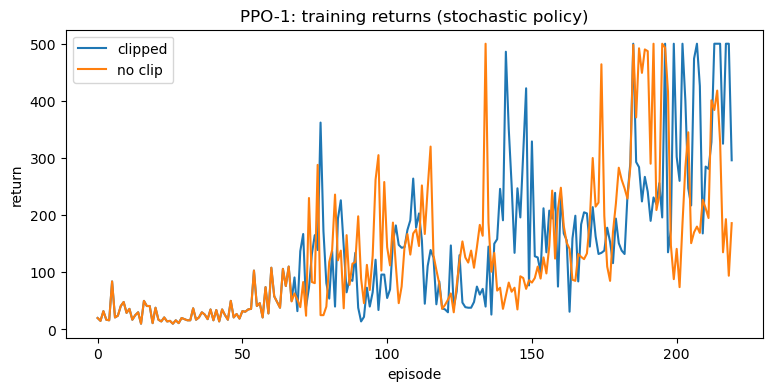

In [11]:
def ppo_policy_loss_no_clip(logp, logp_old, adv, clip_eps):
    ratio = torch.exp(logp - logp_old)
    return -(ratio * adv).mean()

# clipped
actor_c, critic_c, st_c = train_ppo_runner(
    seed=0, episodes=220,
    policy_loss_fn=ppo_policy_loss_clipped,
    gae_fn=compute_gae,
    lam=0.95,
    clip_eps=0.2,
    adv_norm_fn=lambda a: (a - a.mean()) / (a.std() + 1e-8),
    eval_every=55,
)

# no clip
actor_nc, critic_nc, st_nc = train_ppo_runner(
    seed=0, episodes=220,
    policy_loss_fn=ppo_policy_loss_no_clip,
    gae_fn=compute_gae,
    lam=0.95,
    clip_eps=0.2,
    adv_norm_fn=lambda a: (a - a.mean()) / (a.std() + 1e-8),
    eval_every=55,
)

m_c, s_c   = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_c, ob), episodes=30, seed=123)
m_nc, s_nc = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_nc, ob), episodes=30, seed=123)

print("=== EX PPO-1: greedy eval (30 ep) ===")
print(f"clipped   : {m_c:.1f} ± {s_c:.1f}")
print(f"no clip   : {m_nc:.1f} ± {s_nc:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_c["returns"], label="clipped")
plt.plot(st_nc["returns"], label="no clip")
plt.title("PPO-1: training returns (stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


# Ćwiczenie PPO-2 — Normalizacja advantage (stabilność PPO)

## Ćwiczenie PPO-2 — Normalizacja advantage

**Cel:** sprawdzić wpływ normalizacji advantage na stabilność PPO.

Zadanie: uzupełnij `ppo_normalize_adv`.


## TODO:

In [12]:
def ppo_normalize_adv(adv: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    adv: (T,)
    TODO: zwróć (adv - mean) / (std + eps)
    """
    raise NotImplementedError("TODO: normalize adv for PPO")


## Rozwiązanie:

In [13]:
def ppo_normalize_adv(adv: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return (adv - adv.mean()) / (adv.std() + eps)


ep   20 | return=  18.0 | MA50=  14.2 | polL=-5.746 | valL=5.447
ep   40 | return=  33.0 | MA50=  15.4 | polL=-7.132 | valL=7.359
   [eval] ep   55 | greedy mean±std =   22.8 ±  4.1
ep   60 | return=  25.0 | MA50=  18.4 | polL=-2.286 | valL=5.082
ep   80 | return=  36.0 | MA50=  27.0 | polL=0.021 | valL=7.181
ep  100 | return= 119.0 | MA50=  41.4 | polL=-6.307 | valL=8.620
   [eval] ep  110 | greedy mean±std =  460.3 ± 53.2
ep  120 | return= 146.0 | MA50=  69.3 | polL=0.001 | valL=6.417
ep  140 | return= 162.0 | MA50= 114.8 | polL=6.248 | valL=9.543
ep  160 | return= 243.0 | MA50= 166.9 | polL=3.486 | valL=4.617
   [eval] ep  165 | greedy mean±std =  428.4 ± 93.0
ep  180 | return= 363.0 | MA50= 233.6 | polL=0.146 | valL=4.970
ep  200 | return= 161.0 | MA50= 308.9 | polL=8.133 | valL=8.142
ep  220 | return= 192.0 | MA50= 377.0 | polL=7.150 | valL=7.844
   [eval] ep  220 | greedy mean±std =  459.9 ± 45.8
ep   20 | return=  18.0 | MA50=  20.1 | polL=-0.006 | valL=5.276
ep   40 | return=  

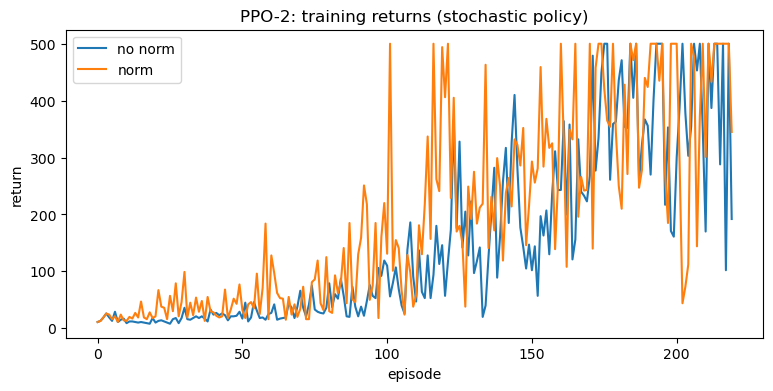

In [14]:
# bez normalizacji
actor_n0, critic_n0, st_n0 = train_ppo_runner(
    seed=1, episodes=220,
    policy_loss_fn=ppo_policy_loss_clipped,
    gae_fn=compute_gae,
    lam=0.95,
    clip_eps=0.2,
    adv_norm_fn=None,
    eval_every=55,
)

# z normalizacją
actor_n1, critic_n1, st_n1 = train_ppo_runner(
    seed=1, episodes=220,
    policy_loss_fn=ppo_policy_loss_clipped,
    gae_fn=compute_gae,
    lam=0.95,
    clip_eps=0.2,
    adv_norm_fn=ppo_normalize_adv,
    eval_every=55,
)

m0, s0 = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_n0, ob), episodes=30, seed=123)
m1, s1 = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_n1, ob), episodes=30, seed=123)

print("=== EX PPO-2: greedy eval (30 ep) ===")
print(f"no norm: {m0:.1f} ± {s0:.1f}")
print(f"norm   : {m1:.1f} ± {s1:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_n0["returns"], label="no norm")
plt.plot(st_n1["returns"], label="norm")
plt.title("PPO-2: training returns (stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


# Ćwiczenie PPO-3 — Implementacja GAE (most do A2C/PPO)

## Ćwiczenie PPO-3 — Implementacja GAE

**Cel:** samemu zaimplementować Generalized Advantage Estimation.

Rekurencja:
- $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ (z maską na done)
- $GAE_t = \delta_t + \gamma\lambda\,GAE_{t+1}$

**Zadanie:** uzupełnij `compute_gae_todo`.


## TODO:

In [15]:
def compute_gae_todo(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    rewards: list length T
    values:  np.array length T+1
    dones:   list length T

    TODO:
    - przejdź t od T-1 do 0
    - mask = 0 gdy done, inaczej 1
    - delta = r_t + gamma*values[t+1]*mask - values[t]
    - gae = delta + gamma*lam*mask*gae
    - adv[t] = gae
    - ret = adv + values[:-1]
    """
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0

    # TODO: pętla wstecz, policz adv
    raise NotImplementedError("TODO: implement GAE loop")

    # TODO: ret
    raise NotImplementedError("TODO: compute returns from adv and values")


## Rozwiązanie:

In [16]:
def compute_gae_todo(rewards, values, dones, gamma=0.99, lam=0.95):
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        mask = 0.0 if dones[t] else 1.0
        delta = rewards[t] + gamma * values[t+1] * mask - values[t]
        gae = delta + gamma * lam * mask * gae
        adv[t] = gae
    ret = adv + values[:-1]
    return adv, ret


ep   20 | return=  29.0 | MA50=  24.6 | polL=-0.007 | valL=7.389
ep   40 | return=  23.0 | MA50=  26.8 | polL=-0.006 | valL=6.120
   [eval] ep   55 | greedy mean±std =  132.3 ± 155.1
ep   60 | return=  74.0 | MA50=  28.0 | polL=0.083 | valL=9.209
ep   80 | return=  92.0 | MA50=  43.4 | polL=0.005 | valL=10.216
ep  100 | return=  50.0 | MA50=  64.0 | polL=-0.006 | valL=13.640
   [eval] ep  110 | greedy mean±std =  345.6 ± 90.7
ep  120 | return= 122.0 | MA50=  96.6 | polL=-0.011 | valL=7.694
ep  140 | return= 231.0 | MA50= 143.4 | polL=-0.002 | valL=5.218
ep  160 | return= 277.0 | MA50= 209.0 | polL=-0.017 | valL=4.174
   [eval] ep  165 | greedy mean±std =  436.1 ± 70.5
ep  180 | return= 364.0 | MA50= 278.2 | polL=-0.016 | valL=4.309
ep  200 | return= 500.0 | MA50= 367.5 | polL=-0.009 | valL=3.647
ep  220 | return= 500.0 | MA50= 421.2 | polL=-0.010 | valL=3.142
   [eval] ep  220 | greedy mean±std =  500.0 ±  0.0
ep   20 | return=  29.0 | MA50=  24.6 | polL=-0.007 | valL=7.389
ep   40 | r

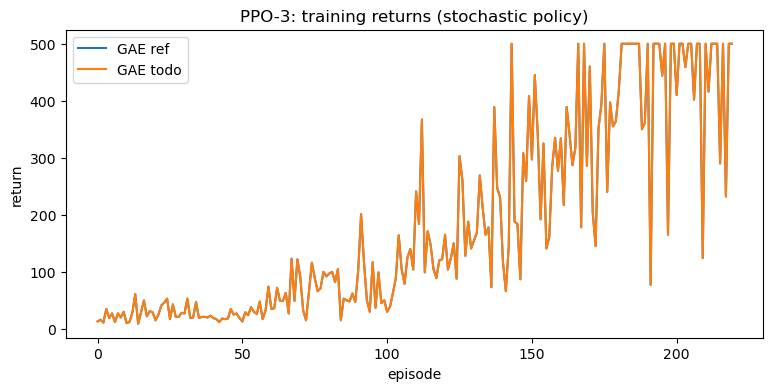

In [17]:
# Porównanie: compute_gae (referencja) vs compute_gae_todo (Twoja implementacja)

actor_ref, critic_ref, st_ref = train_ppo_runner(
    seed=2, episodes=220,
    policy_loss_fn=ppo_policy_loss_clipped,
    gae_fn=compute_gae,
    lam=0.95,
    clip_eps=0.2,
    adv_norm_fn=ppo_normalize_adv,
    eval_every=55,
)

actor_todo, critic_todo, st_todo = train_ppo_runner(
    seed=2, episodes=220,
    policy_loss_fn=ppo_policy_loss_clipped,
    gae_fn=compute_gae_todo,
    lam=0.95,
    clip_eps=0.2,
    adv_norm_fn=ppo_normalize_adv,
    eval_every=55,
)

m_ref, s_ref   = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_ref, ob), episodes=30, seed=123)
m_todo, s_todo = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor_todo, ob), episodes=30, seed=123)

print("=== EX PPO-3: greedy eval (30 ep) ===")
print(f"GAE ref : {m_ref:.1f} ± {s_ref:.1f}")
print(f"GAE todo: {m_todo:.1f} ± {s_todo:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_ref["returns"], label="GAE ref")
plt.plot(st_todo["returns"], label="GAE todo")
plt.title("PPO-3: training returns (stochastic policy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


# Ćwiczenie PPO-4 — wpływ clip_eps (0.1 vs 0.2 vs 0.3)

## Ćwiczenie PPO-4 — Wpływ clip range `clip_eps` na stabilność i tempo uczenia

**Cel:** zobaczyć jak parametr `clip_eps` kontroluje „jak duży krok” może wykonać polityka w jednej aktualizacji.

W PPO używamy clipped surrogate:
- ratio:  $r_t=\exp(\log\pi_\theta - \log\pi_{\theta_{old}})$
- loss:   $L^{CLIP} = -\mathbb{E}[\min(r_t A_t,\ \text{clip}(r_t, 1-\epsilon, 1+\epsilon)A_t)]$

`clip_eps` = $\epsilon$:
- małe (np. 0.1)  → mniejsze, bardziej zachowawcze aktualizacje → często stabilniej, ale wolniej,
- średnie (0.2)   → standardowy kompromis (często działa najlepiej),
- duże (0.3+)     → większe skoki → czasem szybciej, ale rośnie ryzyko niestabilności.

**Zadanie:** napisz funkcję, która uruchomi PPO dla kilku wartości `clip_eps`
i porówna greedy eval oraz przebieg training returns.


## TODO:

In [18]:
def run_clip_sweep(
    clip_list,
    *,
    seed=0,
    episodes=220,
    lam=0.95,
    train_epochs=4,
    batch_size=64,
):
    """
    Uruchom PPO dla każdej wartości clip_eps z clip_list.
    Zwróć listę słowników z wynikami:
      [{"clip": 0.1, "mean": ..., "std": ..., "stats": st}, ...]
    gdzie st to stats zwrócony przez train_ppo_runner.

    TODO:
    - przeiteruj po clip_list
    - odpal train_ppo_runner z policy_loss_fn=ppo_policy_loss_clipped
    - użyj gae_fn=compute_gae i adv_norm_fn=ppo_normalize_adv
    - po treningu policz greedy eval (30 ep) i zapisz do wyników
    """
    results = []

    # TODO: pętla po clip_list
    # for clip in clip_list:
    #   actor, critic, st = train_ppo_runner(...)
    #   mean, std = evaluate_policy(...)
    #   results.append({...})

    raise NotImplementedError("TODO: zaimplementuj sweep po clip_eps")


## ROzwiązanie:

In [19]:
def run_clip_sweep(
    clip_list,
    *,
    seed=0,
    episodes=220,
    lam=0.95,
    train_epochs=4,
    batch_size=64,
):
    results = []
    for clip in clip_list:
        print(f"\n=== PPO clip sweep: clip_eps={clip} ===")
        actor, critic, st = train_ppo_runner(
            seed=seed,
            episodes=episodes,
            policy_loss_fn=ppo_policy_loss_clipped,
            gae_fn=compute_gae,
            lam=lam,
            clip_eps=clip,
            train_epochs=train_epochs,
            batch_size=batch_size,
            adv_norm_fn=ppo_normalize_adv,
            eval_every=55,
        )
        mean, std = evaluate_policy(
            "CartPole-v1",
            lambda ob: a2c_act_greedy(actor, ob),
            episodes=30,
            seed=123,
        )
        results.append({"clip": float(clip), "mean": float(mean), "std": float(std), "stats": st, "actor": actor})
        print(f"[summary] clip={clip} | greedy mean±std = {mean:.1f} ± {std:.1f}")

    return results



=== PPO clip sweep: clip_eps=0.1 ===
ep   20 | return=  11.0 | MA50=  30.4 | polL=-0.009 | valL=3.198
ep   40 | return=  35.0 | MA50=  25.4 | polL=-0.007 | valL=7.316
   [eval] ep   55 | greedy mean±std =   64.3 ± 17.8
ep   60 | return=  52.0 | MA50=  28.7 | polL=-0.007 | valL=7.834
ep   80 | return= 113.0 | MA50=  47.0 | polL=-0.018 | valL=12.524
ep  100 | return=  40.0 | MA50=  75.2 | polL=-0.007 | valL=18.139
   [eval] ep  110 | greedy mean±std =  444.2 ± 43.3
ep  120 | return= 174.0 | MA50= 102.0 | polL=-0.007 | valL=7.854
ep  140 | return= 119.0 | MA50= 120.8 | polL=-0.012 | valL=11.700
ep  160 | return= 142.0 | MA50= 165.9 | polL=0.021 | valL=9.271
   [eval] ep  165 | greedy mean±std =  438.0 ± 71.5
ep  180 | return= 318.0 | MA50= 189.9 | polL=-0.006 | valL=6.942
ep  200 | return= 401.0 | MA50= 231.8 | polL=-0.016 | valL=1.450
ep  220 | return= 500.0 | MA50= 261.5 | polL=-0.004 | valL=2.069
   [eval] ep  220 | greedy mean±std =  337.9 ± 83.9
[summary] clip=0.1 | greedy mean±std 

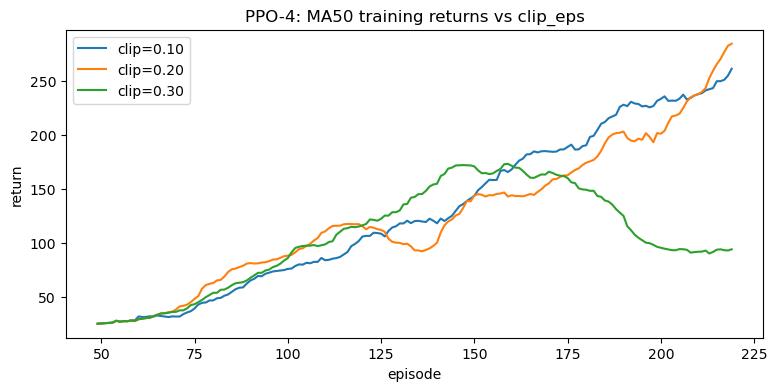

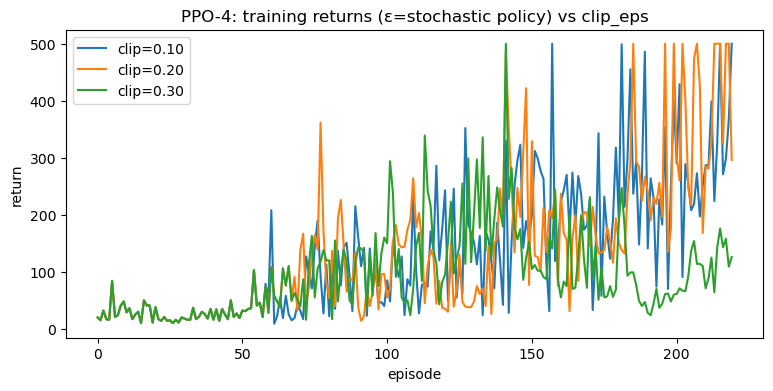

In [20]:
clip_list = [0.1, 0.2, 0.3]
results = run_clip_sweep(
    clip_list,
    seed=0,
    episodes=220,
    lam=0.95,
    train_epochs=4,
    batch_size=64,
)

print("\n=== EX PPO-4: PODSUMOWANIE (greedy eval, 30 ep) ===")
for r in results:
    print(f"clip_eps={r['clip']:.2f}  ->  {r['mean']:.1f} ± {r['std']:.1f}")

# wykres: MA50 return dla różnych clip_eps
plt.figure(figsize=(9,4))
for r in results:
    rets = r["stats"]["returns"]
    ma = moving_average(rets, 50)
    if len(ma) > 0:
        xs = np.arange(len(ma)) + 49
        plt.plot(xs, ma, label=f"clip={r['clip']:.2f}")
    else:
        plt.plot(rets, label=f"clip={r['clip']:.2f}")

plt.title("PPO-4: MA50 training returns vs clip_eps")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

# (opcjonalnie) surowe returns (może być głośne, ale czasem edukacyjne)
plt.figure(figsize=(9,4))
for r in results:
    plt.plot(r["stats"]["returns"], label=f"clip={r['clip']:.2f}")
plt.title("PPO-4: training returns (ε=stochastic policy) vs clip_eps")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


## Bonus - multiseed:

In [21]:
def run_clip_multiseed(clip_list, seeds=(0,1,2), episodes=180):
    table = []
    for clip in clip_list:
        means = []
        for sd in seeds:
            actor, critic, st = train_ppo_runner(
                seed=sd,
                episodes=episodes,
                policy_loss_fn=ppo_policy_loss_clipped,
                gae_fn=compute_gae,
                lam=0.95,
                clip_eps=clip,
                train_epochs=4,
                batch_size=64,
                adv_norm_fn=ppo_normalize_adv,
                eval_every=0,
            )
            m, _ = evaluate_policy("CartPole-v1", lambda ob: a2c_act_greedy(actor, ob), episodes=20, seed=123)
            means.append(m)
        table.append((clip, float(np.mean(means)), float(np.std(means))))
    return table

tbl = run_clip_multiseed([0.1,0.2,0.3], seeds=(0,1,2), episodes=180)
print("=== PPO-4 multi-seed (mean over seeds) ===")
for clip, m, s in tbl:
    print(f"clip_eps={clip:.2f} -> mean={m:.1f}  (std_over_seeds={s:.1f})")


ep   20 | return=  11.0 | MA50=  30.4 | polL=-0.009 | valL=3.198
ep   40 | return=  35.0 | MA50=  25.4 | polL=-0.007 | valL=7.316
ep   60 | return=  52.0 | MA50=  28.7 | polL=-0.007 | valL=7.834
ep   80 | return= 113.0 | MA50=  47.0 | polL=-0.018 | valL=12.524
ep  100 | return=  40.0 | MA50=  75.2 | polL=-0.007 | valL=18.139
ep  120 | return= 174.0 | MA50= 102.0 | polL=-0.007 | valL=7.854
ep  140 | return= 119.0 | MA50= 120.8 | polL=-0.012 | valL=11.700
ep  160 | return= 142.0 | MA50= 165.9 | polL=0.021 | valL=9.271
ep  180 | return= 318.0 | MA50= 189.9 | polL=-0.006 | valL=6.942
ep   20 | return=  18.0 | MA50=  20.1 | polL=-0.006 | valL=5.276
ep   40 | return=  30.0 | MA50=  30.7 | polL=-0.008 | valL=6.024
ep   60 | return=  42.0 | MA50=  39.1 | polL=-0.007 | valL=7.027
ep   80 | return=  11.0 | MA50=  49.0 | polL=-0.010 | valL=13.695
ep  100 | return=  41.0 | MA50=  49.4 | polL=-0.004 | valL=8.843
ep  120 | return= 108.0 | MA50=  43.2 | polL=-0.004 | valL=11.287
ep  140 | return= 129